# imports and setup

In [1]:
from pathlib import Path

import torch

# custom utils
from trnbl.loggers.wandb import WandbLogger


from attention_motifs.vit_ae import VitAEConfig, VitAE
from attention_motifs.train import get_dataset, set_up_model, train
from attention_motifs.dataset.dataset import DataloaderMock

f:\projects\attention-motifs\.venv\Lib\site-packages\trnbl\loggers\base.py:17: UserWarning: GPUtil not available: No module named 'GPUtil'
  warnings.warn(f"GPUtil not available: {e}")


In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

# Configuration

In [3]:
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# training data
ACTIVATIONS_PATH: Path = Path("../data/activations/medium")
BATCH_SIZE: int = 10
N_TRAIN_BATCHES: int = 50

# validation data
VAL_ACTIVATIONS_PATH: Path = Path("../data/activations/small_val")
VAL_BATCH_SIZE: int = 8
N_VAL_BATCHES: int = 8

# model
MODEL_CONFIG: VitAEConfig = VitAEConfig(
	d_latent=128,
	num_epochs=1,
)

# get data

{
  "n_total_samples": 406808,
  "n_prompts": 599,
  "n_datasets": 9,
  "config": {
    "prompts_config": {
      "name": "pile_50",
      "source_path": "../data/pile_50.jsonl",
      "char_len_min": 64,
      "char_len_max": 256
    },
    "model_names": [
      "pythia-14m",
      "gpt2-small",
      "meta-llama/Llama-3.2-1B"
    ],
    "token_len_min": 16,
    "prompt_token_len_tolerance": 16,
    "raw_scores": false
  },
  "dataset_shapes_summary": [
    "(52256, 64, 64)",
    "(289408, 48, 48)",
    "(6648, 80, 80)",
    "(42464, 32, 32)",
    "(11560, 16, 16)",
    "(2024, 96, 96)",
    "(288, 112, 112)",
    "(1872, 128, 128)",
    "(288, 144, 144)"
  ]
}
loader: 50 batches, 500 samples
AttentionPatternMetadata(model_name='gpt2-small', idx_layer=10, idx_head=6, n_ctx=80, prompt_hash=1505588144)


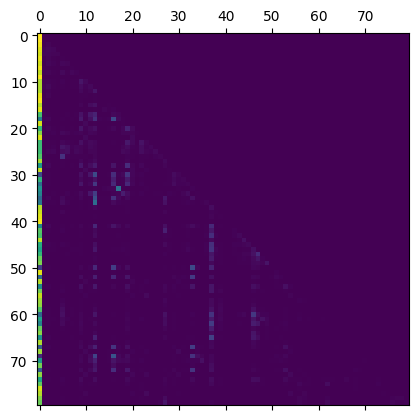

{
  "n_total_samples": 35360,
  "n_prompts": 52,
  "n_datasets": 5,
  "config": {
    "prompts_config": {
      "name": "pile_5_val",
      "source_path": "data/pile_5_val.jsonl",
      "char_len_min": 64,
      "char_len_max": 256
    },
    "model_names": [
      "pythia-14m",
      "gpt2-small",
      "meta-llama/Llama-3.2-1B"
    ],
    "token_len_min": 16,
    "prompt_token_len_tolerance": 16,
    "raw_scores": false
  },
  "dataset_shapes_summary": [
    "(5688, 32, 32)",
    "(24760, 48, 48)",
    "(3552, 64, 64)",
    "(680, 80, 80)",
    "(680, 16, 16)"
  ]
}
loader: 8 batches, 64 samples
AttentionPatternMetadata(model_name='pythia-14m', idx_layer=0, idx_head=0, n_ctx=32, prompt_hash=array([4240000085, 3049883931, 3150279530,  243925532, 2391240854,
        841440317, 4179210227, 3047535130, 4240000085, 3049883931],
      dtype=uint64))


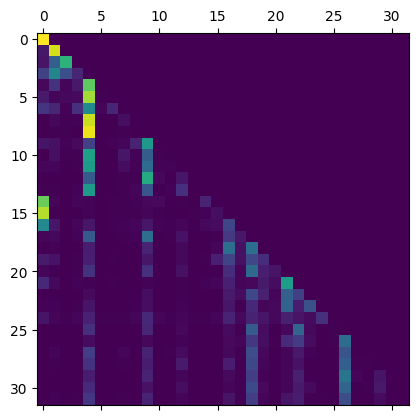

In [4]:
TRAIN_LOADER: DataloaderMock
TRAIN_LOADER, DATASET_INFO, _, _ = get_dataset(
	activations_path=ACTIVATIONS_PATH,
	batch_size=BATCH_SIZE,
	n_batches=N_TRAIN_BATCHES,
)

VAL_LOADER: DataloaderMock
VAL_LOADER, VAL_DATASET_INFO, _, _ = get_dataset(
	activations_path=VAL_ACTIVATIONS_PATH,
	batch_size=VAL_BATCH_SIZE,
	n_batches=N_VAL_BATCHES,
	shuffle=False,
)

# set up model and train

In [5]:
MODEL, OPTIMIZER, LR_SCHEDULER = set_up_model(
	config=MODEL_CONFIG,
	model_cls=VitAE,
	device=DEVICE,
)

model has 367762 (368K) parameters


In [6]:
# init logger
LOGGER: WandbLogger = WandbLogger.create(
	config=dict(
		model_config=MODEL.zanj_model_config.serialize(),
		dataset_info=DATASET_INFO,
		val_dataset_info=VAL_DATASET_INFO,
		model_str=str(MODEL),
		device=str(DEVICE),
	),
	project="vit-ae",
	# name="vit-ae" + datetime.datetime.now().strftime("-%Y-%m-%d-%H-%M-%S"),
)

MODEL = train(
	logger=LOGGER,
	device=DEVICE,
	model=MODEL,
	optimizer=OPTIMIZER,
	lr_scheduler=LR_SCHEDULER,
	train_loader=TRAIN_LOADER,
	val_loader=VAL_LOADER,
)

wandb: Currently logged in as: miv to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


2025-01-30 05:46:38 INFO config ={'model_config': {'__format__': 'VitAEConfig(SerializableDataclass)', 'act_fn': 'GELU', 'd_latent': 128, 'd_model': 64, 'patch_size': 4, 'max_patches': 64, 'num_heads': 8, 'mlp_dim': 256, 'encoder_depth': 2, 'decoder_depth': 2, 'contrast_temperature': 0.1, 'recon_weight': 1.0, 'contrast_weight': 0.1, 'num_epochs': 1, 'optimizer': 'Adam', 'learning_rate': 0.0001, 'lr_scheduler': 'ReduceLROnPlateau', 'lr_scheduler_kwargs': {'mode': 'min', 'factor': 0.1, 'patience': 10, 'threshold': 0.0001, 'threshold_mode': 'rel', 'cooldown': 0, 'min_lr': 1e-06, 'eps': 1e-08}}, 'dataset_info': {'summary_short_str': '{\n  "n_total_samples": 406808,\n  "n_prompts": 599,\n  "n_datasets": 9,\n  "config": {\n    "prompts_config": {\n      "name": "pile_50",\n      "source_path": "../data/pile_50.jsonl",\n      "char_len_min": 64,\n      "char_len_max": 256\n    },\n    "model_names": [\n      "pythia-14m",\n      "gpt2-small",\n      "meta-llama/Llama-3.2-1B"\n    ],\n    "tok

epoch 1/1:   4%|▍         | 2/50 [00:03<01:03,  1.33s/ batches]F:\projects\attention-motifs\attention_motifs\train_util.py:73: UserWarning: No positive pairs found in batch
  warnings.warn("No positive pairs found in batch")
epoch 1/1: 100%|██████████| 50/50 [01:27<00:00,  1.75s/ batches]

2025-01-30 05:48:05 INFO training complete kwargs ={'__complete__': True}


batches,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
elapsed_time,▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇█
epochs,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
latest_checkpoint,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁████████████████████
lr,██████████▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
samples,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train/contrast_loss,▅█▁▁▁▇▁▁▁▁▁▁█▁▁▅▆▁▁▁▁▁▁▁▁▇▁▁▁▁▁▁▆▁▁▁▁▁▁▆
train/loss,▆▅▃▁▁▅▁▁▁▁▂▂█▁▁▅▅▃▂▁▁▃▁▁▁▂▅▁▂▂▂▁▄▃▁▂▁▁▁▄
train/recon_loss,▆▁▇▂▁▂▁▁▂▂▄█▁▁▃▆▁▇▄▁▂▇▂▁▂▆▁▃▄▃▃▃▂▁█▅▂▂▂▁
val/latent_std,█▃▁▁▁▁▁▁▁▁
val/mean_diff,▁▄▆▇██████
